#Продолжительность поездки в такси. EDA

Нужно определить какие факторы и насколько влияют на продолжительность поездки в такси

Поля и их значения:

* `id`: Уникальный идентификатор объекта. Каждый объект в датасете имеет свой уникальный id, который используется для его однозначной идентификации.

* `vendour_id`: Айди компании, предоставляющей услуги.

* `pickup_datetime`: Время забора пассажиров и пассажирих.

* `dropoff_datetime`: Время высадки пассажиров.

* `passenger_count`: Кол-во пассажиров (слава богу целочисленное).

* `pickup_longitude`: Долгота забора пассажириков.

* `pickup_latitude`: Соответственно широта.

* `dropoff_longitude`: Долгота высадки.

* `dropoff_latitude`: Широта высадки.

* `trip_duration`: Продолжительность поездки

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

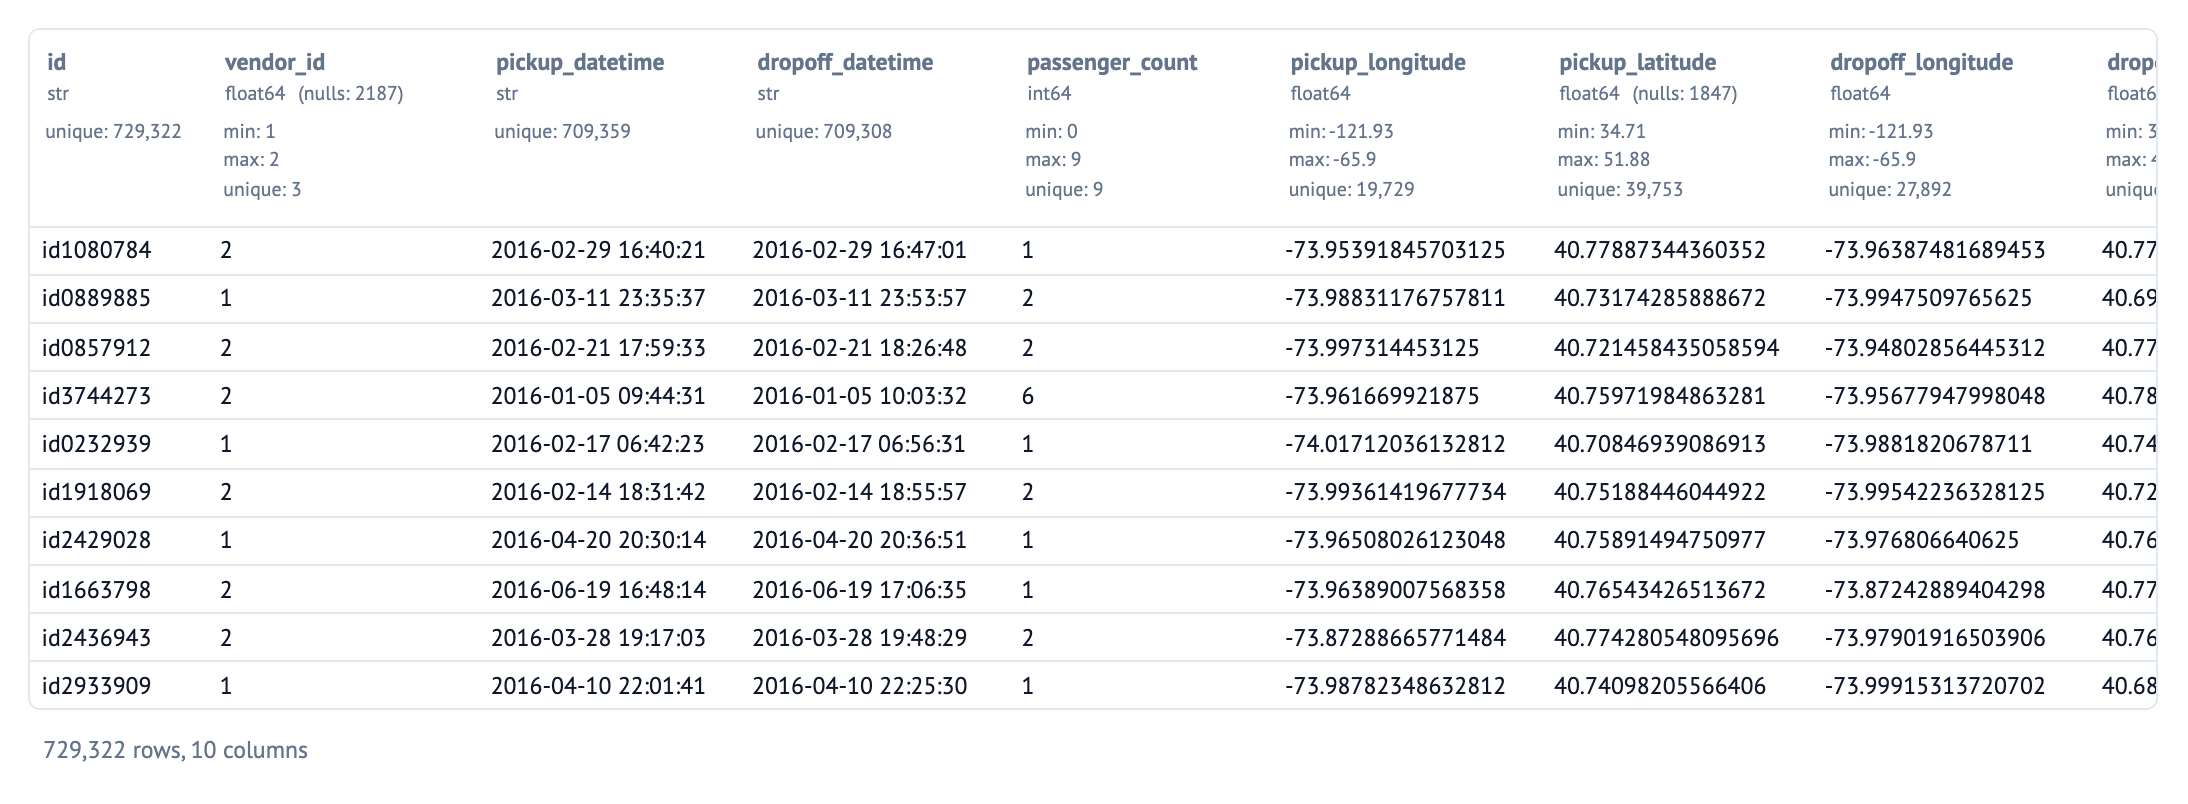

In [ ]:
df_raw = pd.read_csv("./data/raw/trip_duration_task.csv")
df_raw

Удалим `dropff_datetime`, так как это утечка данных (модель может просто вычитать время начала поездки `pickup_datetime` из времени конца поездки `dropoff_datetime`)

In [ ]:
df = df_raw.drop(columns=["dropoff_datetime", "id"])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   vendor_id          727135 non-null  float64
 1   pickup_datetime    729322 non-null  str    
 2   passenger_count    729322 non-null  int64  
 3   pickup_longitude   729322 non-null  float64
 4   pickup_latitude    727475 non-null  float64
 5   dropoff_longitude  729322 non-null  float64
 6   dropoff_latitude   729322 non-null  float64
 7   trip_duration      729322 non-null  int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 44.5 MB


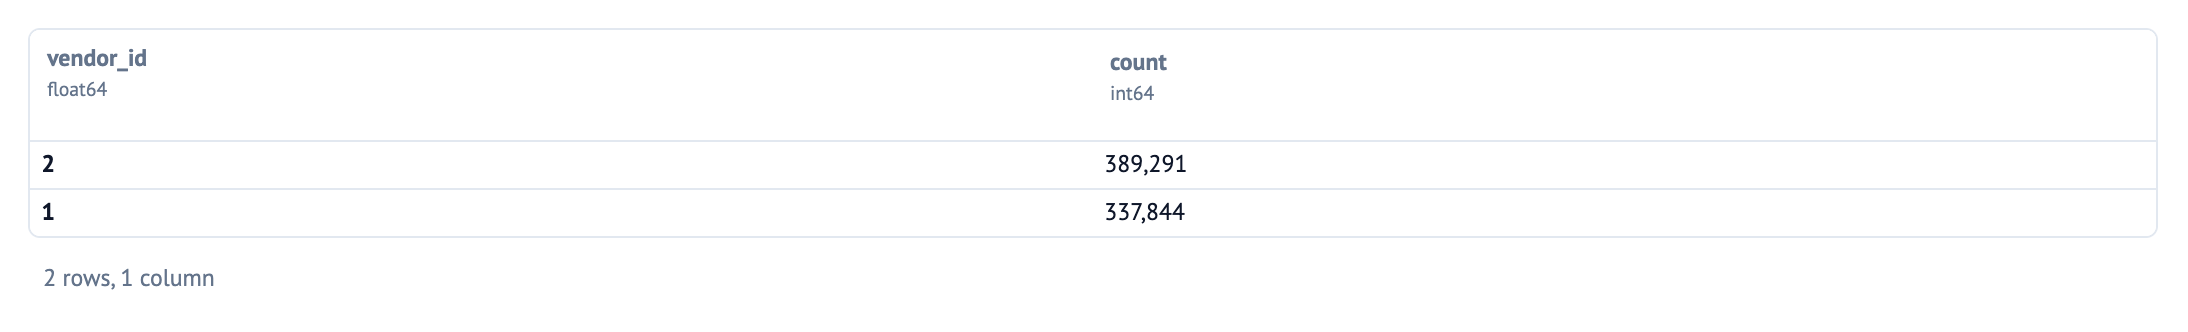

In [ ]:
df["vendor_id"].value_counts()

In [ ]:
def clean_data(df):
    df = df.copy()

    df = df.dropna(subset=["vendor_id"])

    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

    return df

df_clean = clean_data(df)

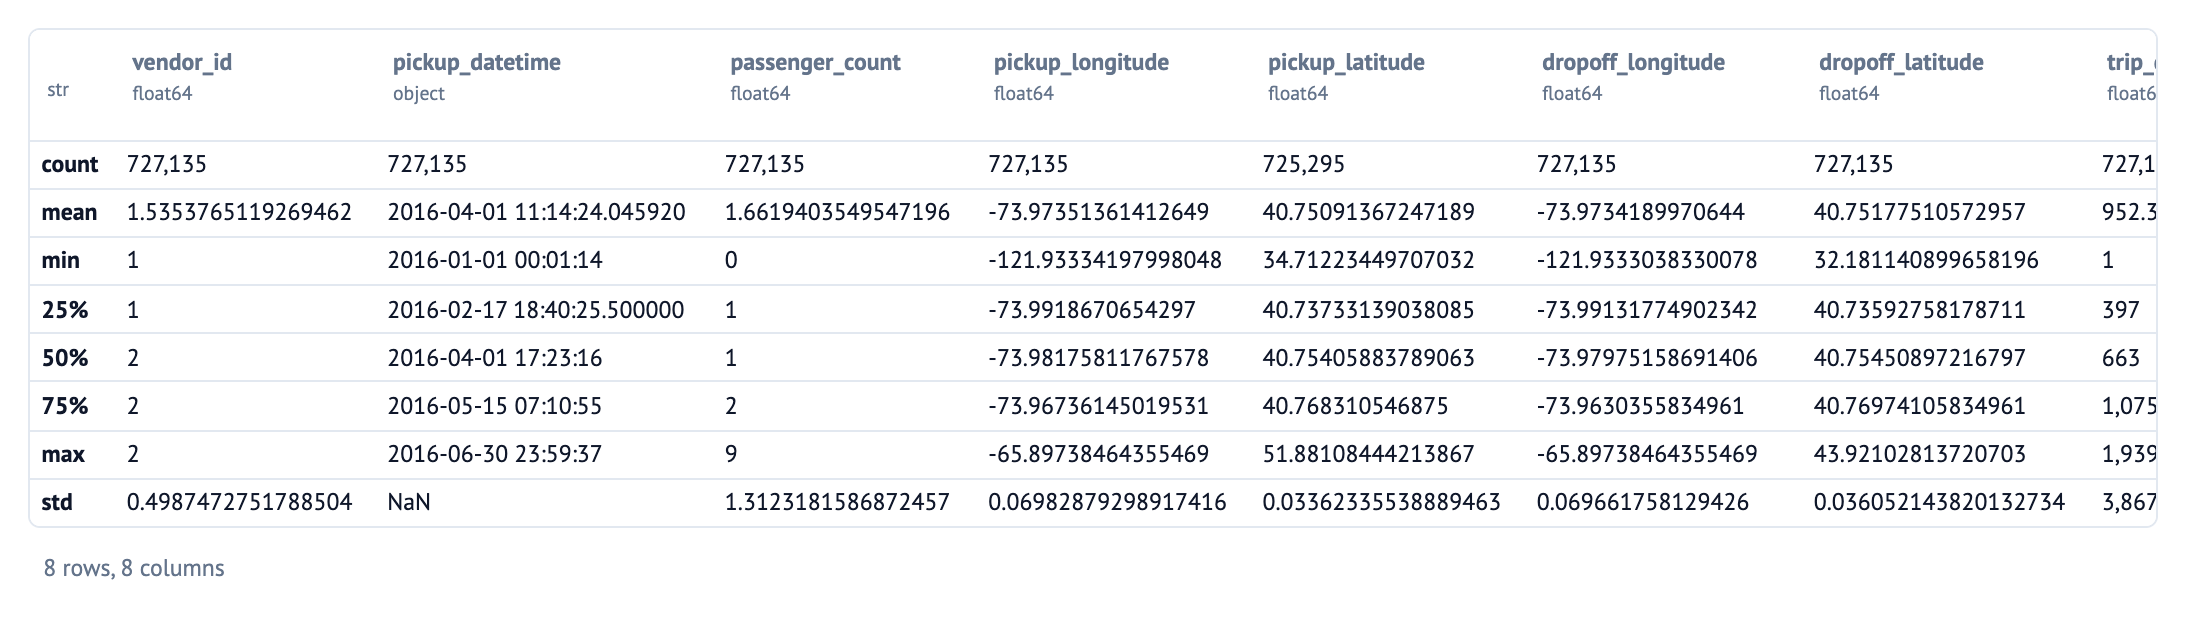

In [ ]:
df_clean.describe()

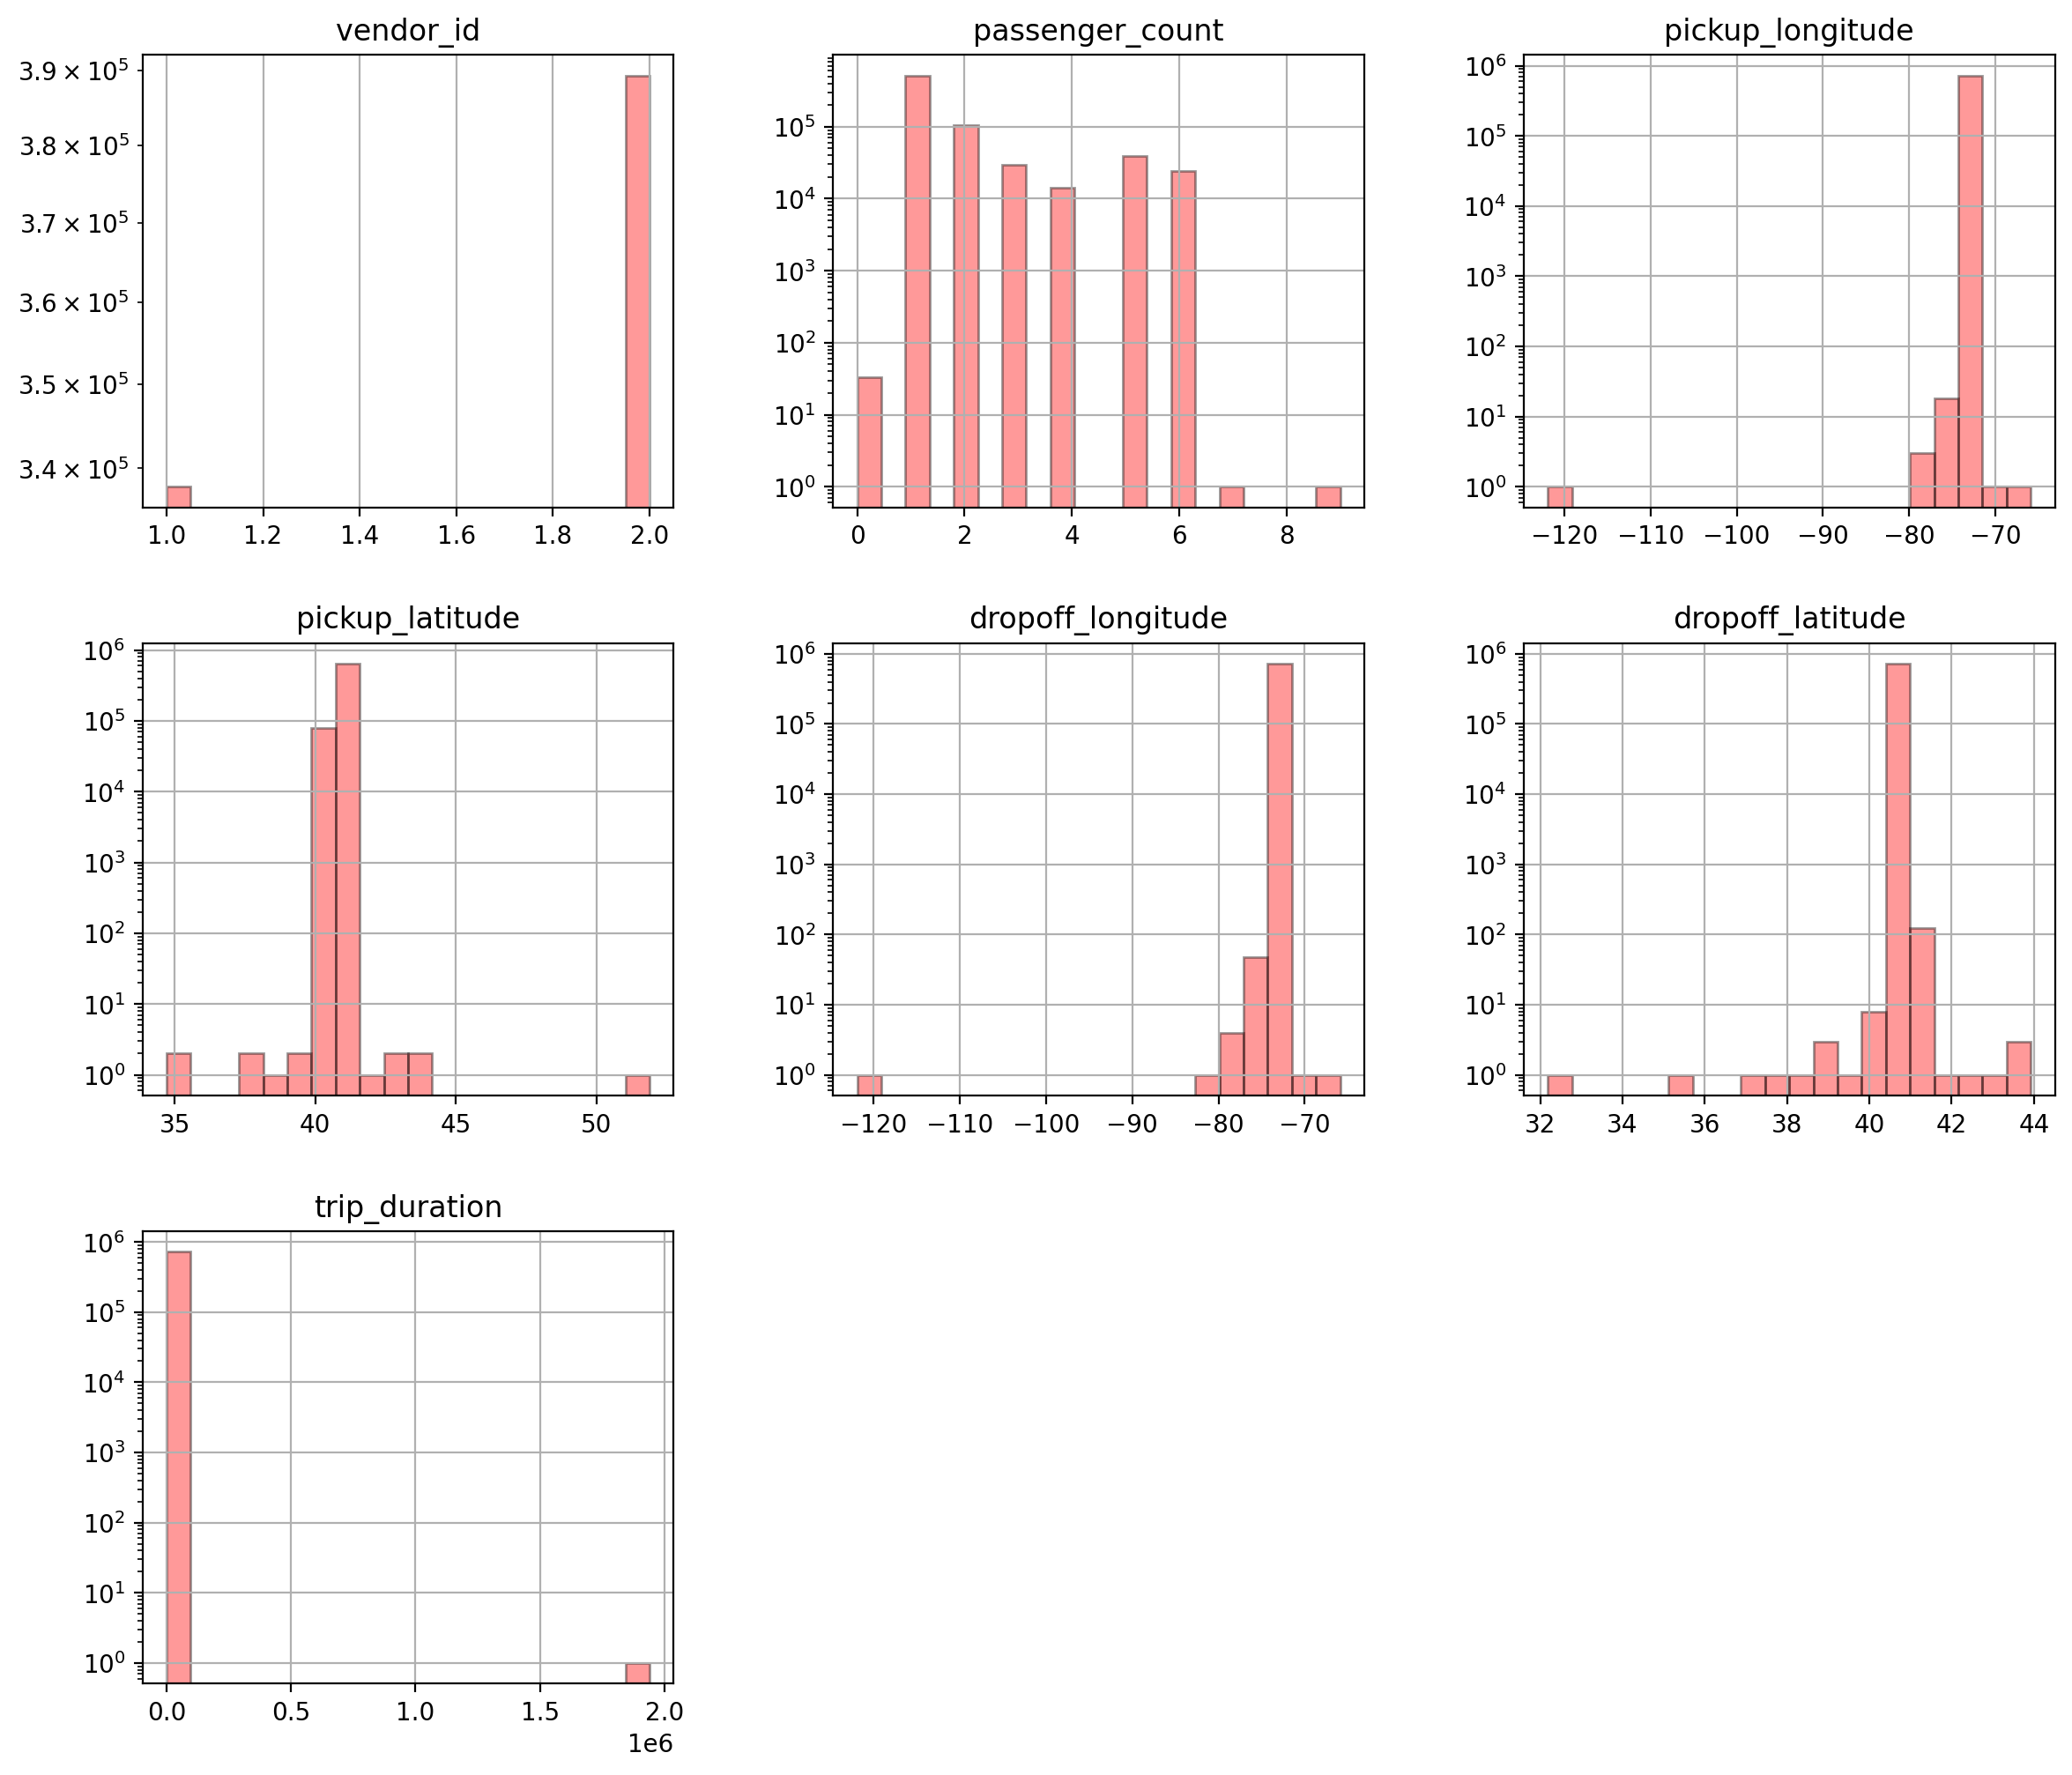

In [ ]:
numeric_cols_df = df_clean.select_dtypes(include=np.number)
numeric_cols_df.hist(
    bins=20, color="red", alpha=0.4, edgecolor="black", figsize=(14, 12), log=True
)
plt.show()

In [ ]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [ ]:
def get_time_of_day(h):
    if 6 <= h < 12:
        return "Morning"
    elif 12 <= h < 16:
        return "Afternoon"
    elif 16 <= h < 22:
        return "Evening"
    else:
        return "Night"

In [ ]:
def add_features(df):
    df = df.copy()

    df["distance_km"] = haversine_np(
        df["pickup_longitude"],
        df["pickup_latitude"],
        df["dropoff_longitude"],
        df["dropoff_latitude"],
    )

    df["hour"] = df["pickup_datetime"].dt.hour
    df["month"] = df["pickup_datetime"].dt.month
    df["weekday"] = df["pickup_datetime"].dt.weekday

    df["hour"] = df["pickup_datetime"].dt.hour

    df["time_of_day"] = df["hour"].apply(get_time_of_day)

    return df

df_enriched = add_features(df_clean)

In [ ]:
def filter_outliers_iqr(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col_name] >= lower) & (data[col_name] <= upper)]

df_filtered = filter_outliers_iqr(df_enriched, "trip_duration")
df_filtered = filter_outliers_iqr(df_filtered, "distance_km")
df_clean.shape[0], df_filtered.shape[0]

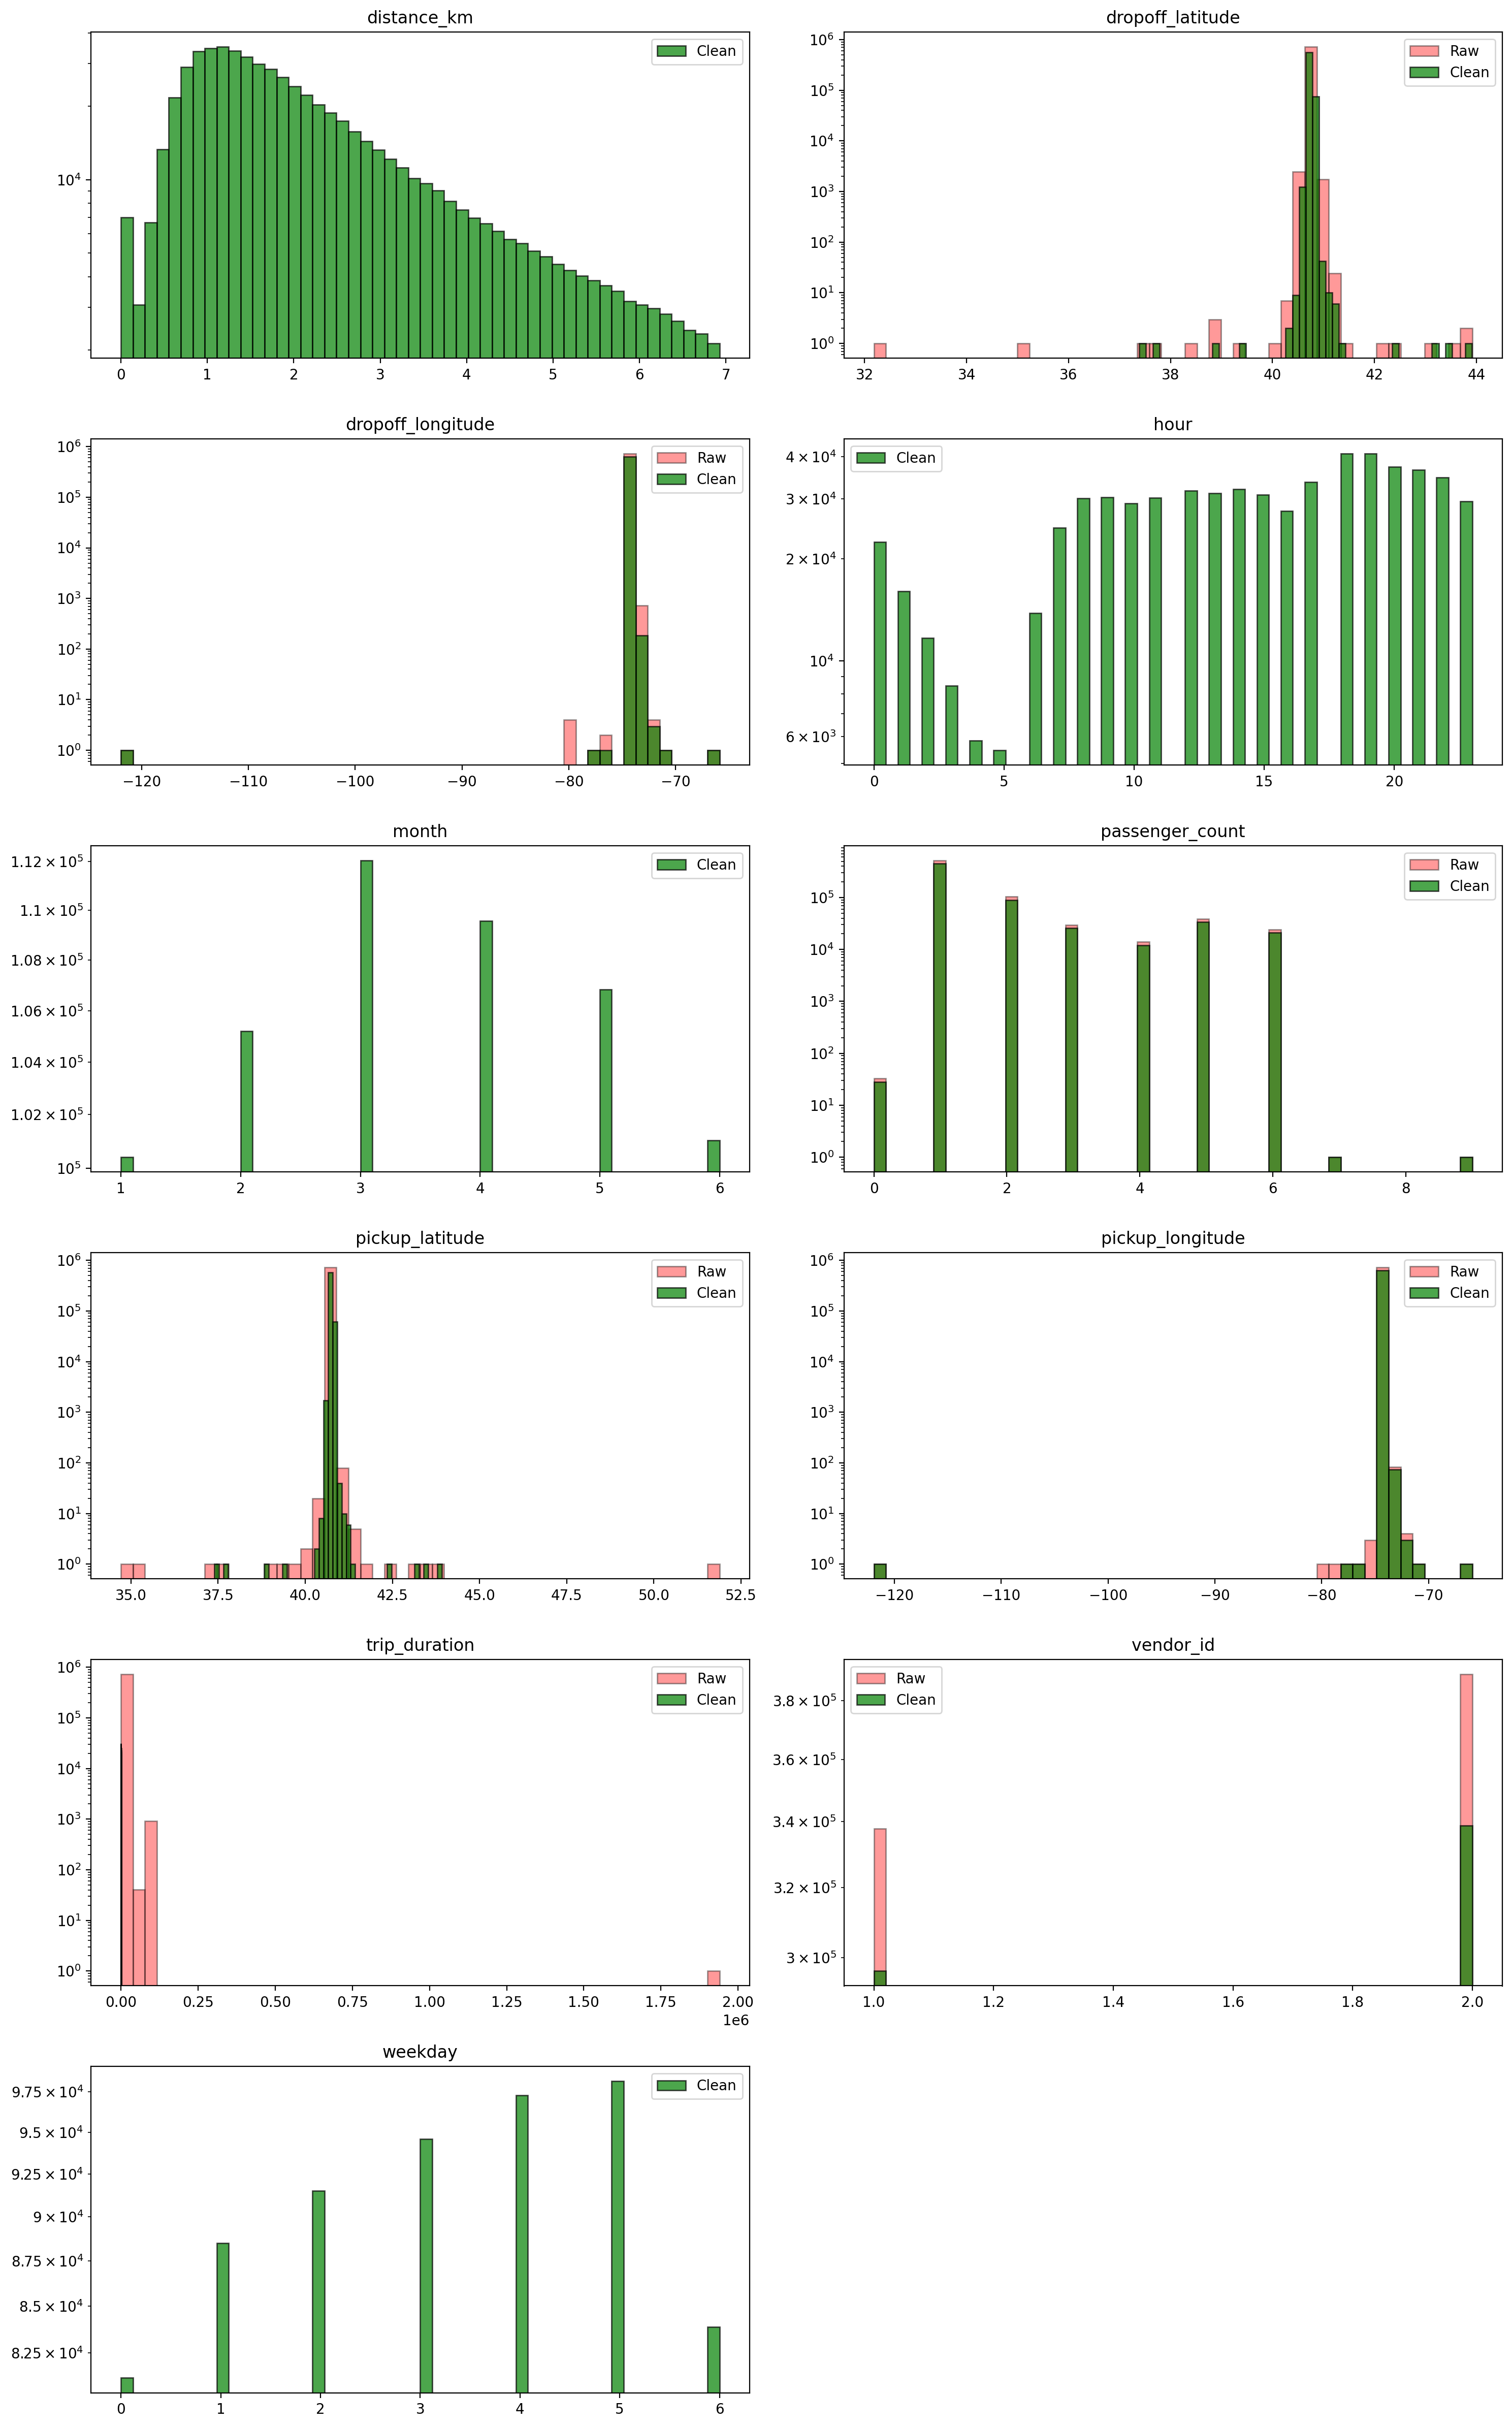

In [ ]:
import math

def plot_overlap_grid(df_raw, df_clean, cols_per_row=2):
    raw_nums = df_raw.select_dtypes(include=[np.number]).columns
    clean_nums = df_clean.select_dtypes(include=[np.number]).columns

    all_cols = sorted(list(set(raw_nums) | set(clean_nums)))
    num_plots = len(all_cols)

    if num_plots == 0:
        return

    num_rows = math.ceil(num_plots / cols_per_row)

    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(15, 4 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(all_cols):
        ax = axes[i]

        if col in df_raw.columns:
            ax.hist(
                df_raw[col].dropna(),
                bins=50,
                color="red",
                edgecolor="black",
                alpha=0.4,
                label="Raw",
                log=True,
            )

        if col in df_clean.columns:
            ax.hist(
                df_clean[col].dropna(),
                bins=50,
                color="green",
                edgecolor="black",
                alpha=0.7,
                label="Clean",
                log=True,
            )

        ax.set_title(col)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    return fig

plot_overlap_grid(df, df_filtered)

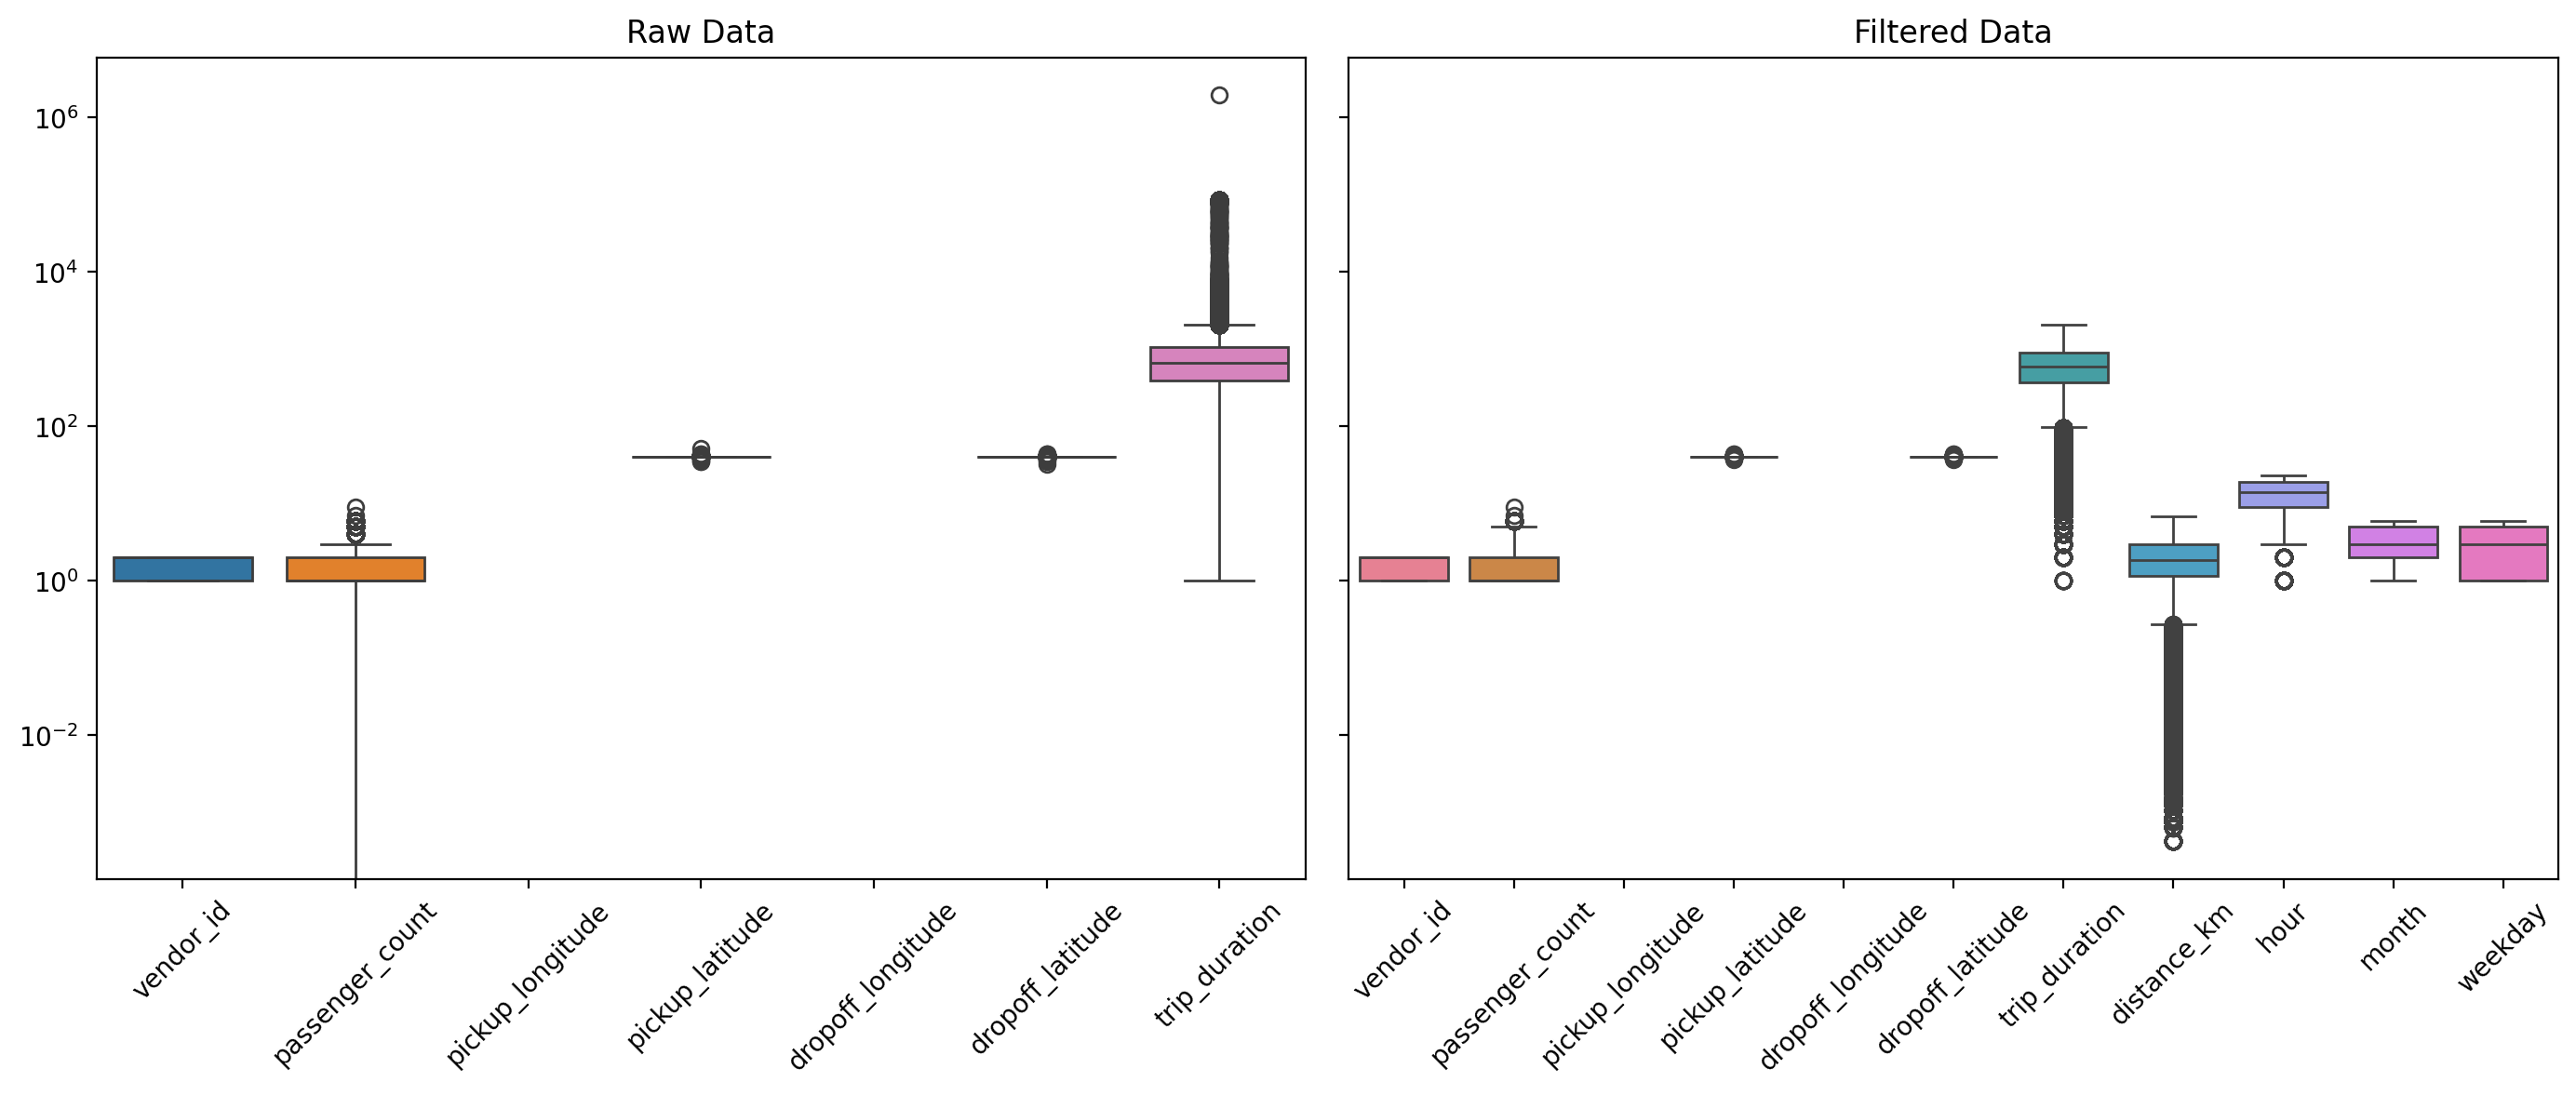

In [ ]:
def graph_outlier_subplots():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.boxplot(data=df, ax=axes[0])
    axes[0].set_title("Raw Data")
    axes[0].set_yscale("log")
    axes[0].tick_params(axis="x", rotation=45)

    sns.boxplot(data=df_filtered, ax=axes[1])
    axes[1].set_title("Filtered Data")
    axes[1].set_yscale("log")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

graph_outlier_subplots()

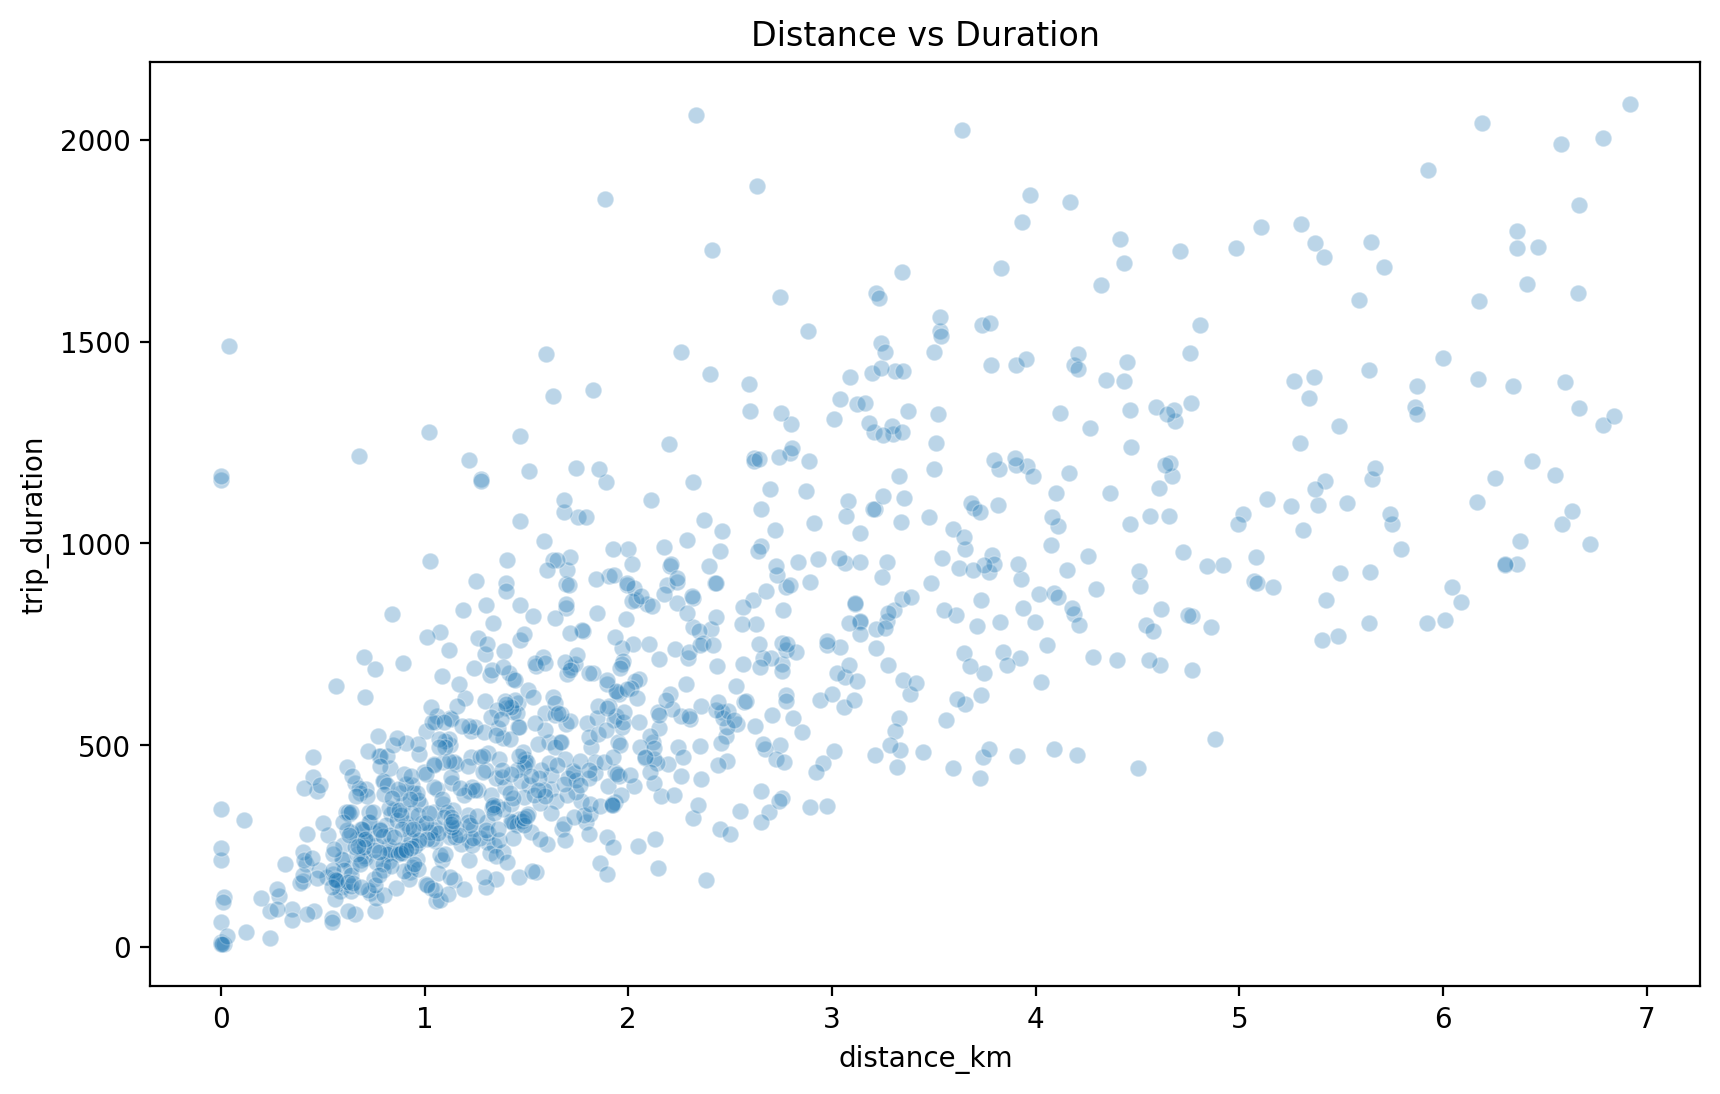

In [ ]:
def plot_scatter():
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(
        x="distance_km",
        y="trip_duration",
        data=df_filtered.sample(1000),
        alpha=0.3,
        ax=ax,
    )
    ax.set_title("Distance vs Duration")
    return fig

plot_scatter()

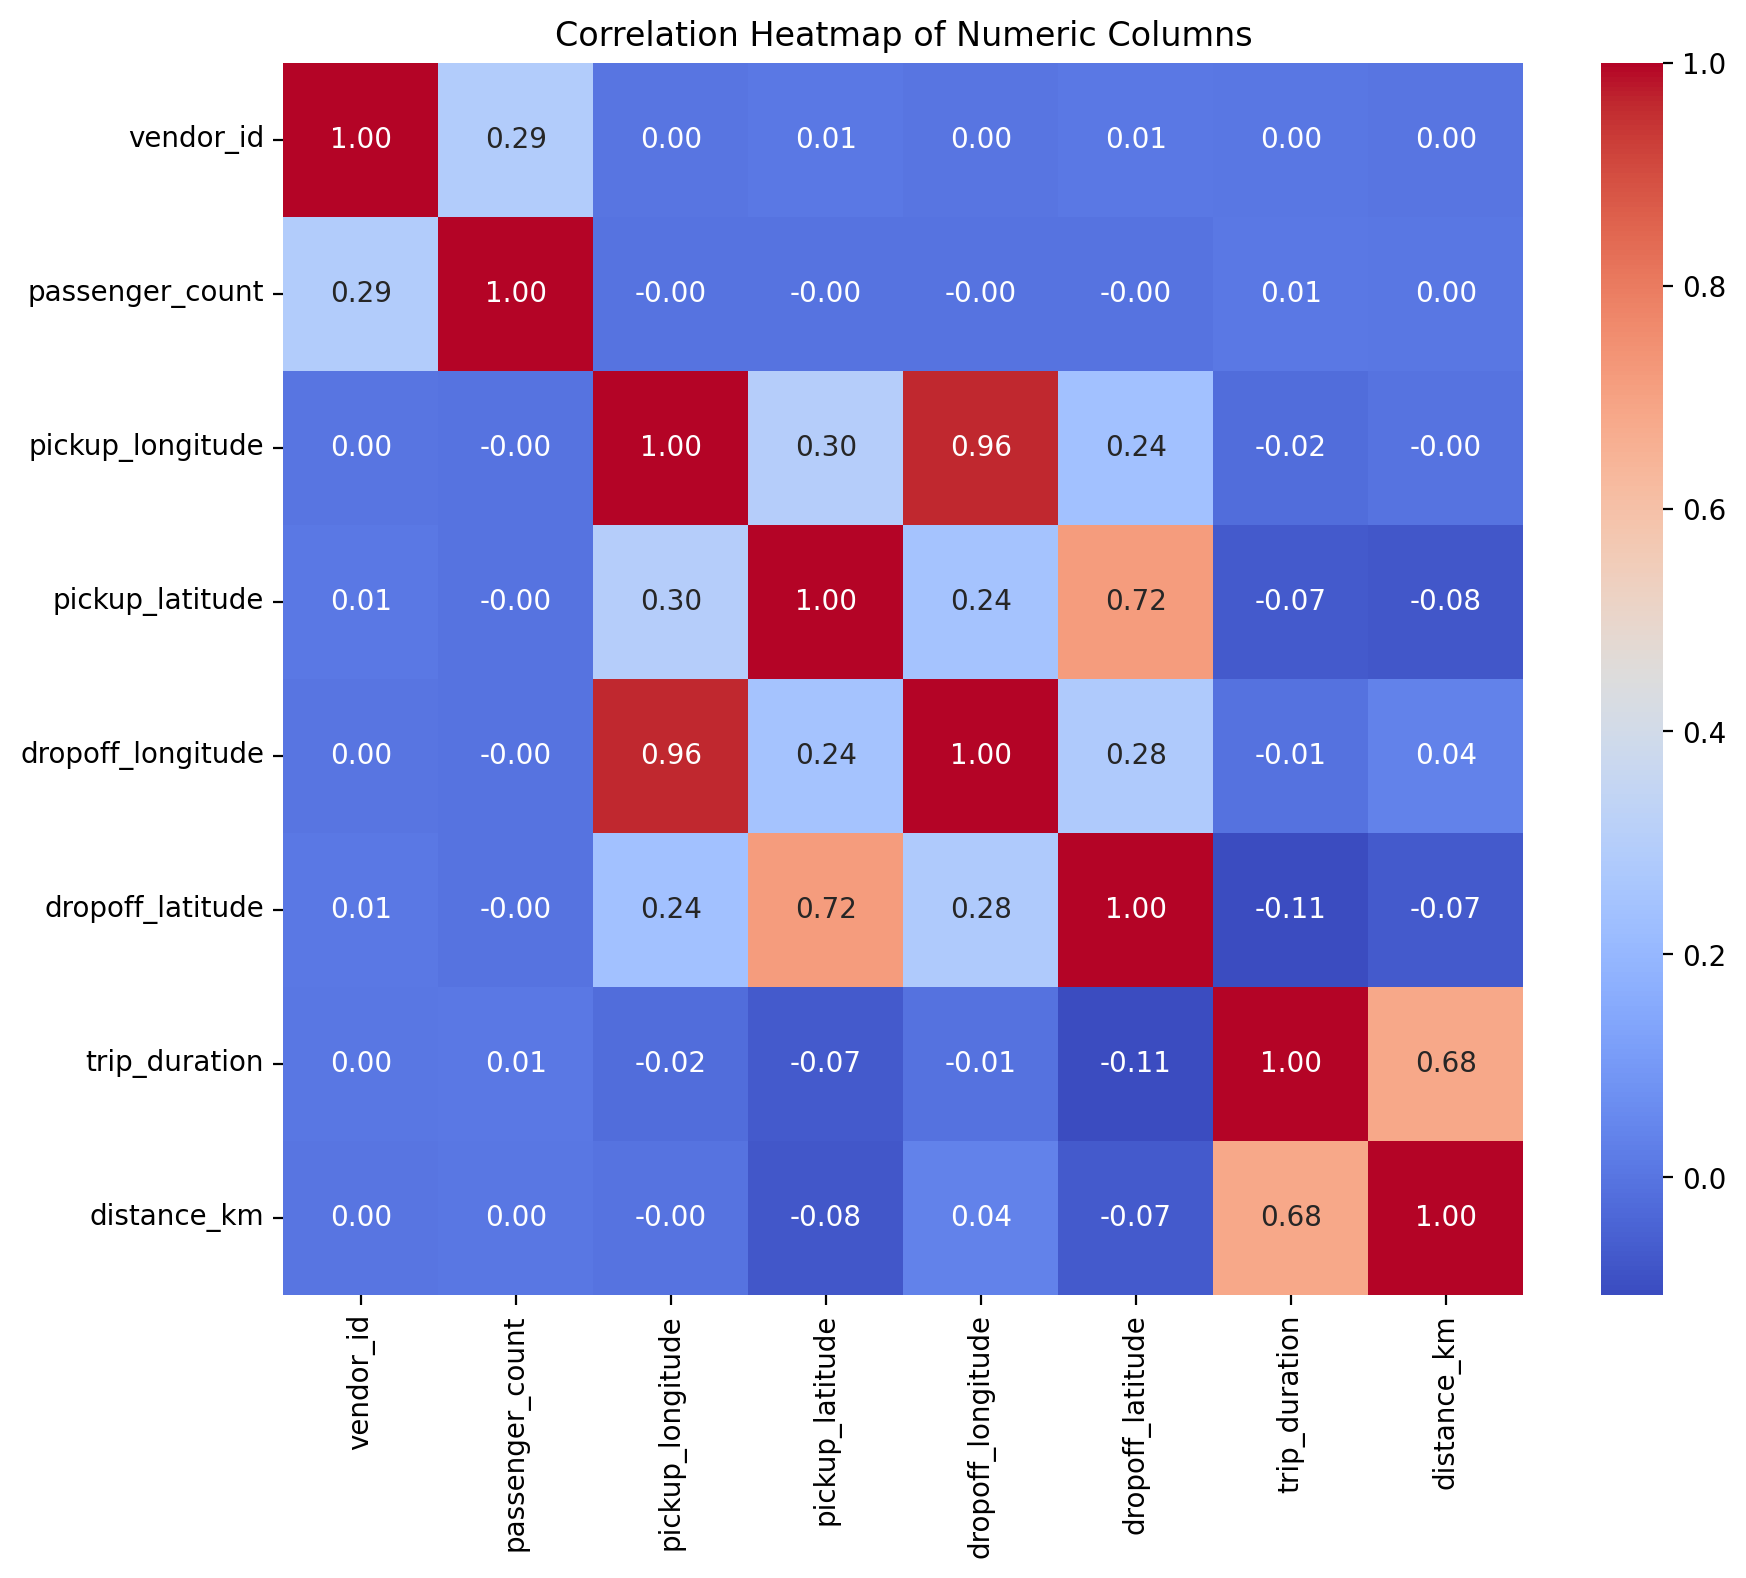

In [ ]:
numeric_df = df_filtered.select_dtypes(include=["float64", "int64"])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()

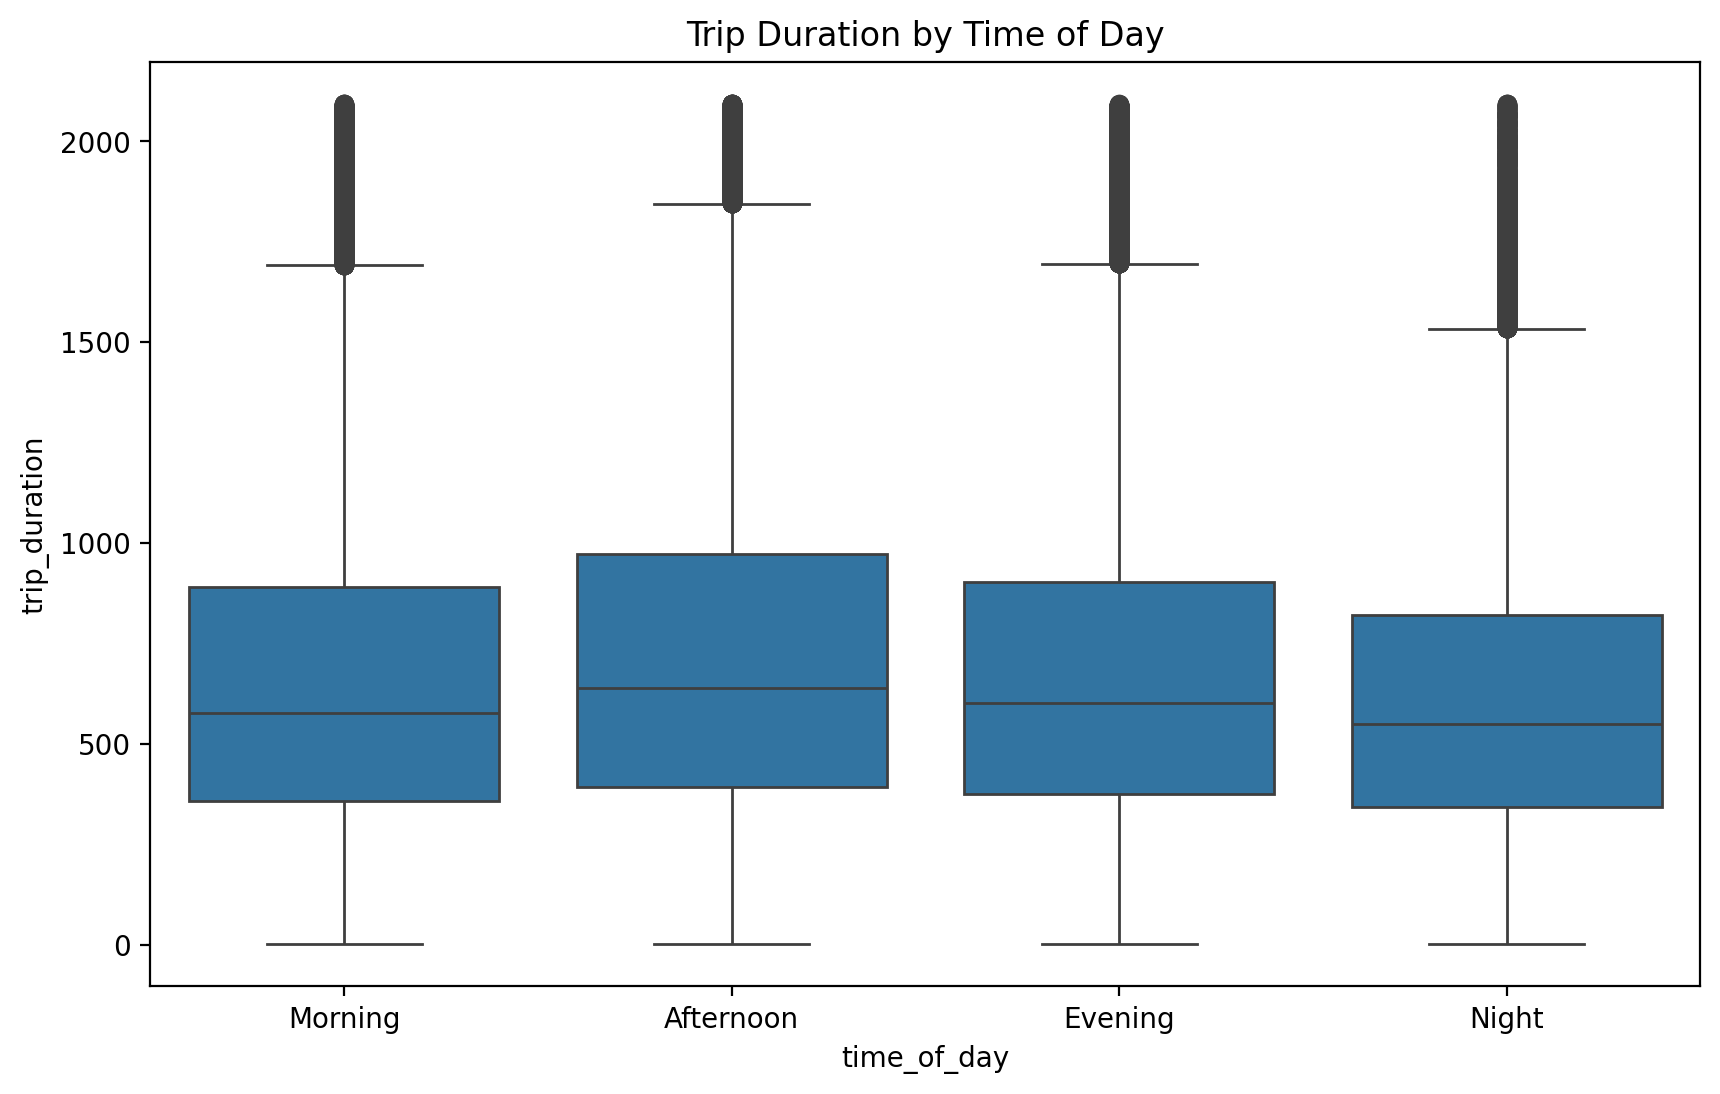

In [ ]:
def plot_boxplot_time():
    fig, ax = plt.subplots(figsize=(10, 6))
    order = ["Morning", "Afternoon", "Evening", "Night"]
    sns.boxplot(
        x="time_of_day", y="trip_duration", data=df_filtered, order=order, ax=ax
    )
    ax.set_title("Trip Duration by Time of Day")
    return fig

plot_boxplot_time()

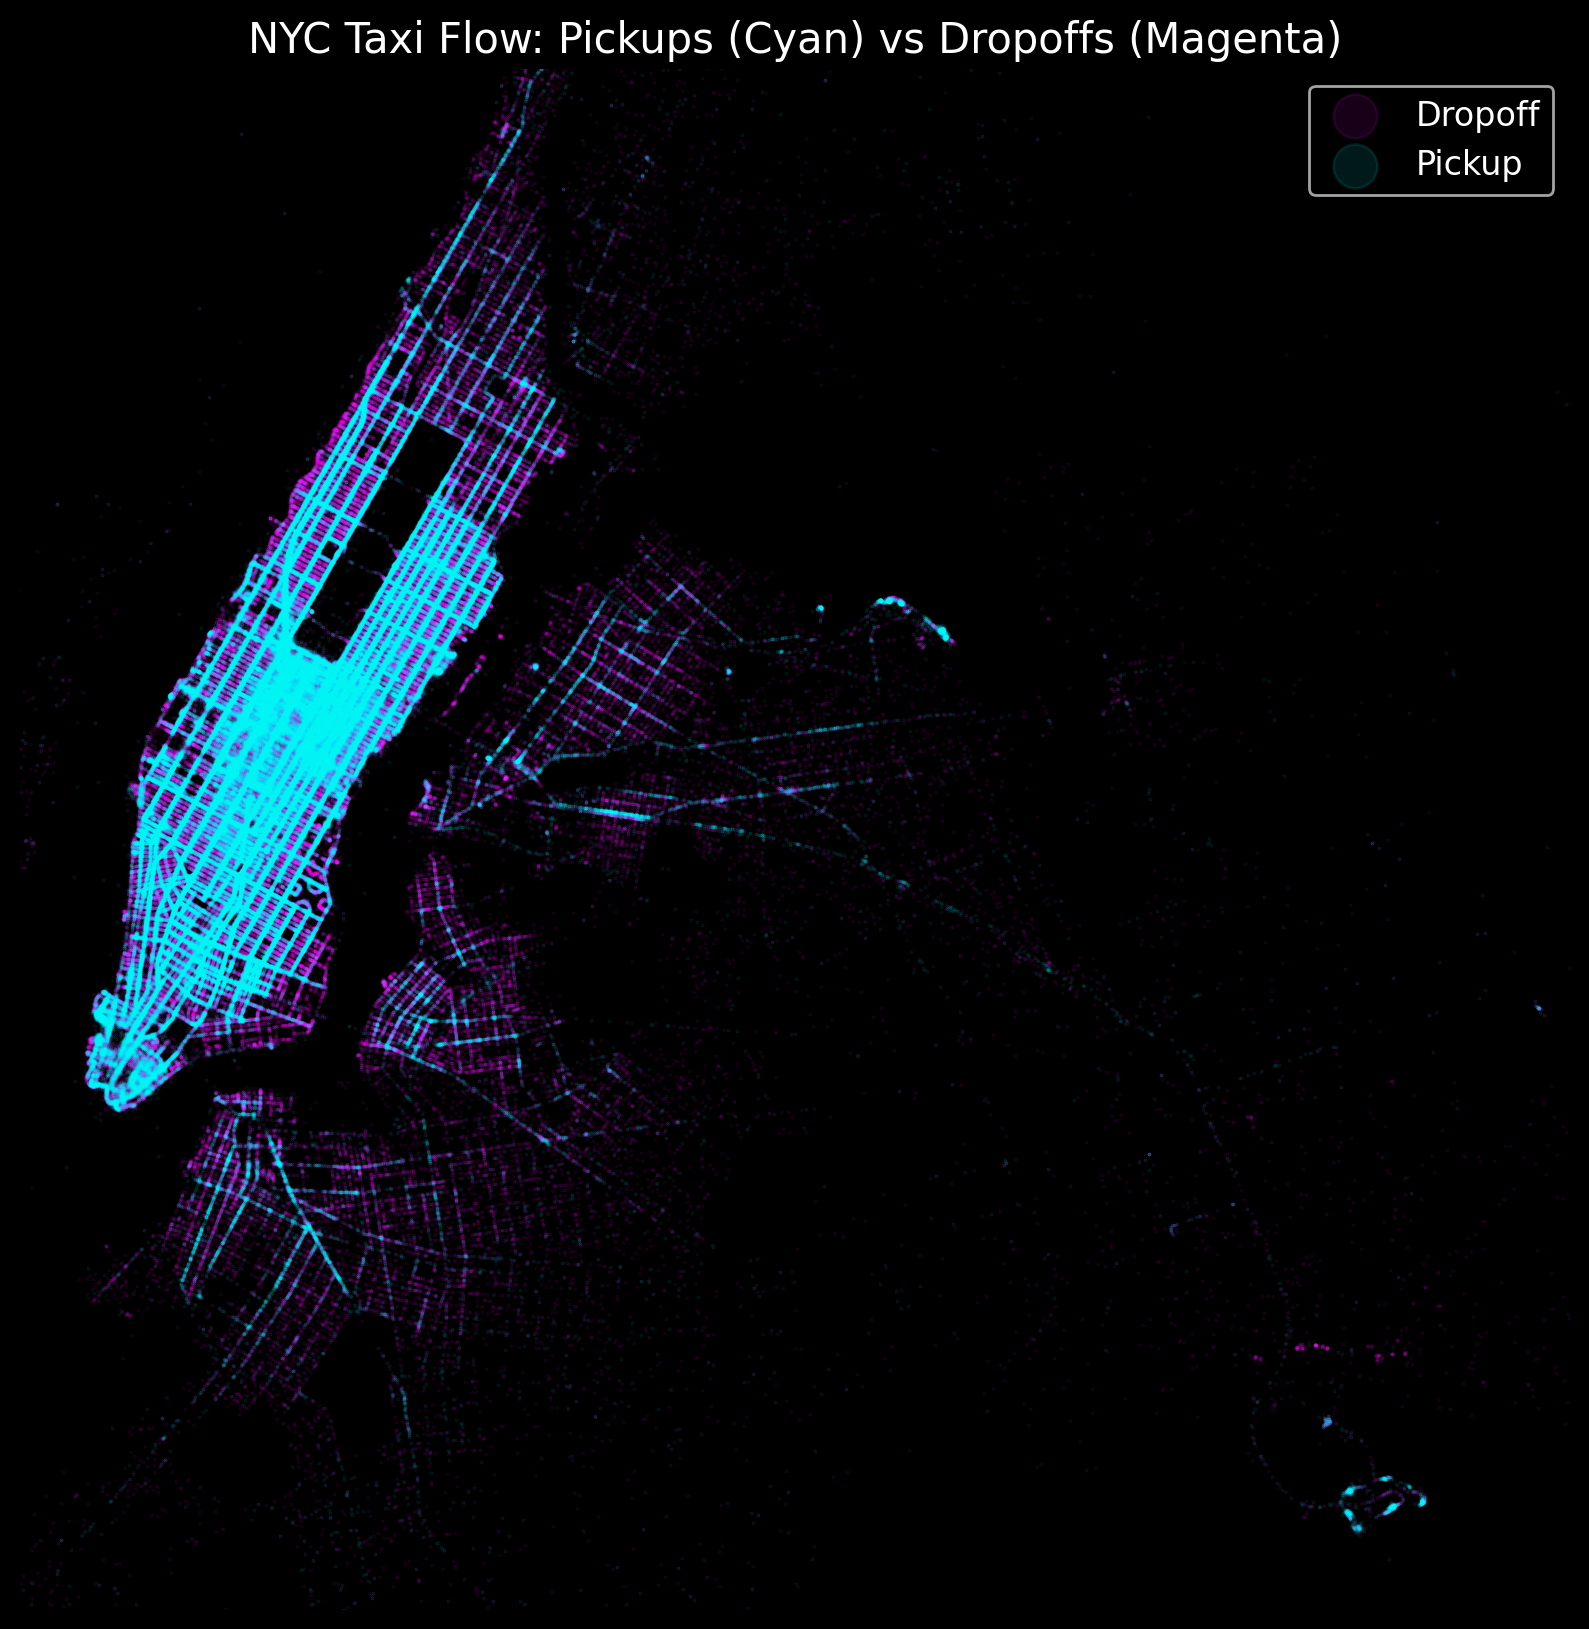

In [ ]:
def plot_nyc_map():
    plt.style.use("dark_background")
    fig, ax = plt.subplots(figsize=(10, 10))

    xlim = [-74.03, -73.75]
    ylim = [40.63, 40.85]

    ax.scatter(
        df_filtered["dropoff_longitude"],
        df_filtered["dropoff_latitude"],
        s=0.1,
        alpha=0.1,
        color="#ff00ff",
        label="Dropoff",
    )

    ax.scatter(
        df_filtered["pickup_longitude"],
        df_filtered["pickup_latitude"],
        s=0.1,
        alpha=0.1,
        color="#00ffff",
        label="Pickup",
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_axis_off()

    ax.legend(fontsize=12, markerscale=50)

    ax.set_title(
        "NYC Taxi Flow: Pickups (Cyan) vs Dropoffs (Magenta)",
        fontsize=15,
        color="white",
    )

    plt.style.use("default")

    return fig

plot_nyc_map()

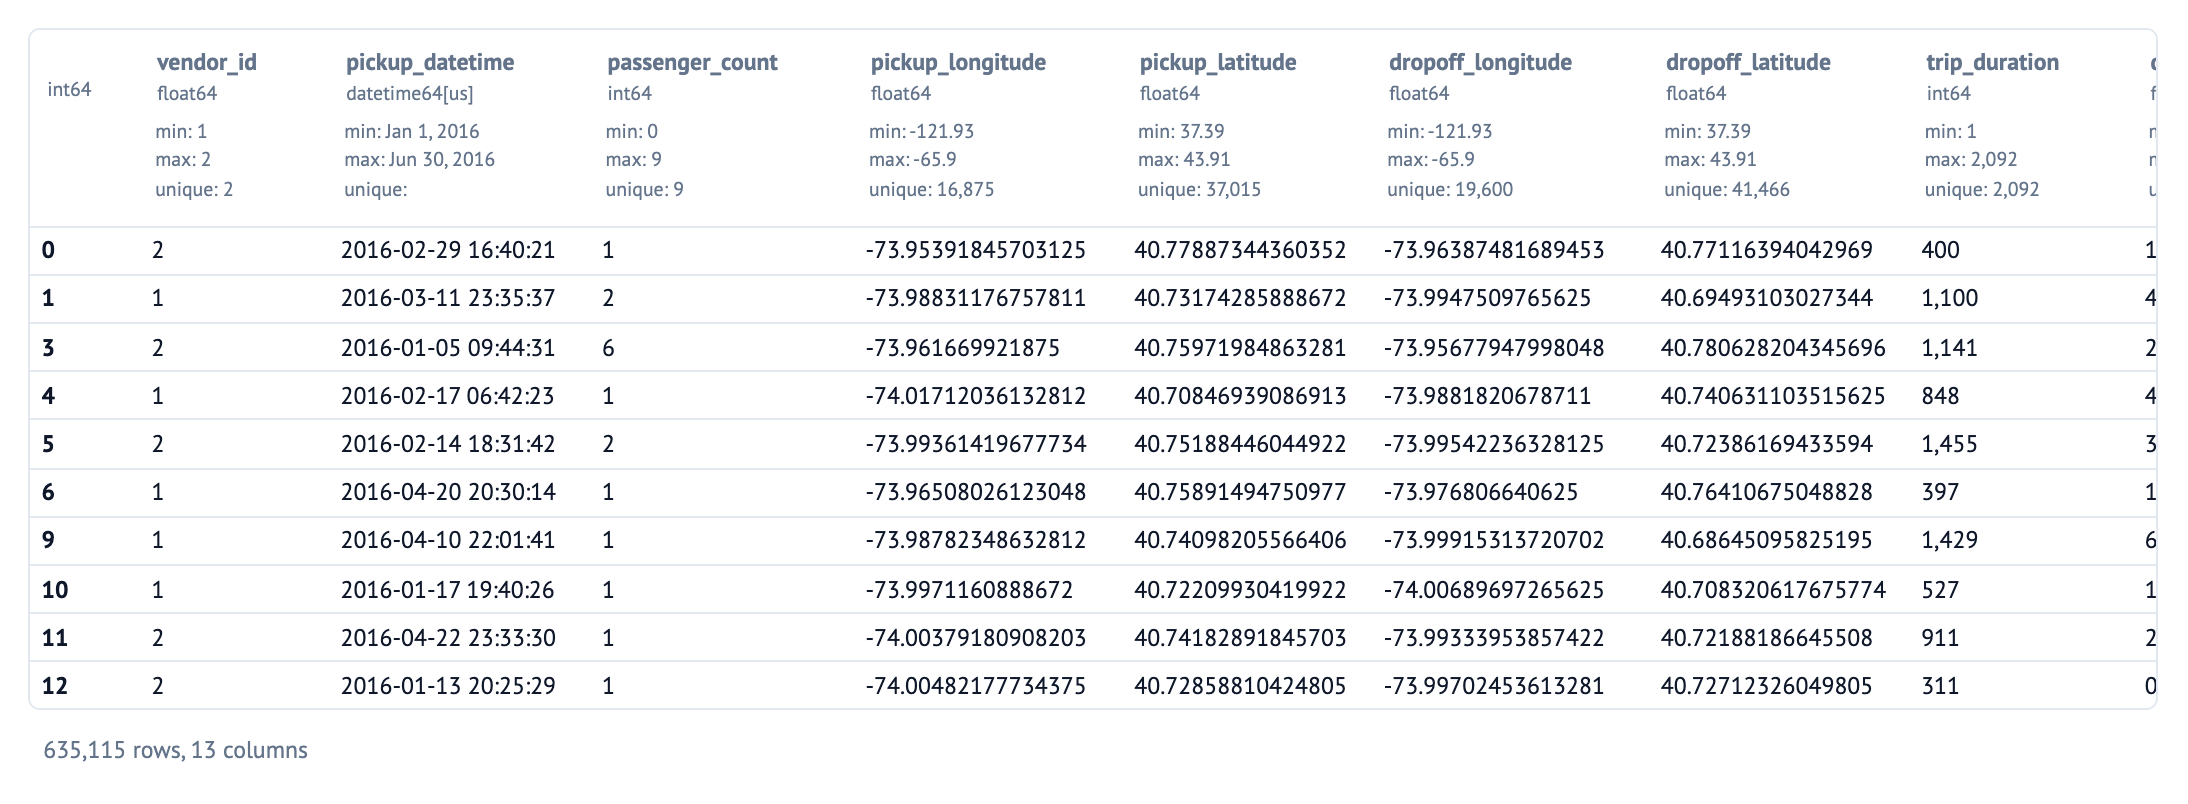

In [ ]:
df_filtered

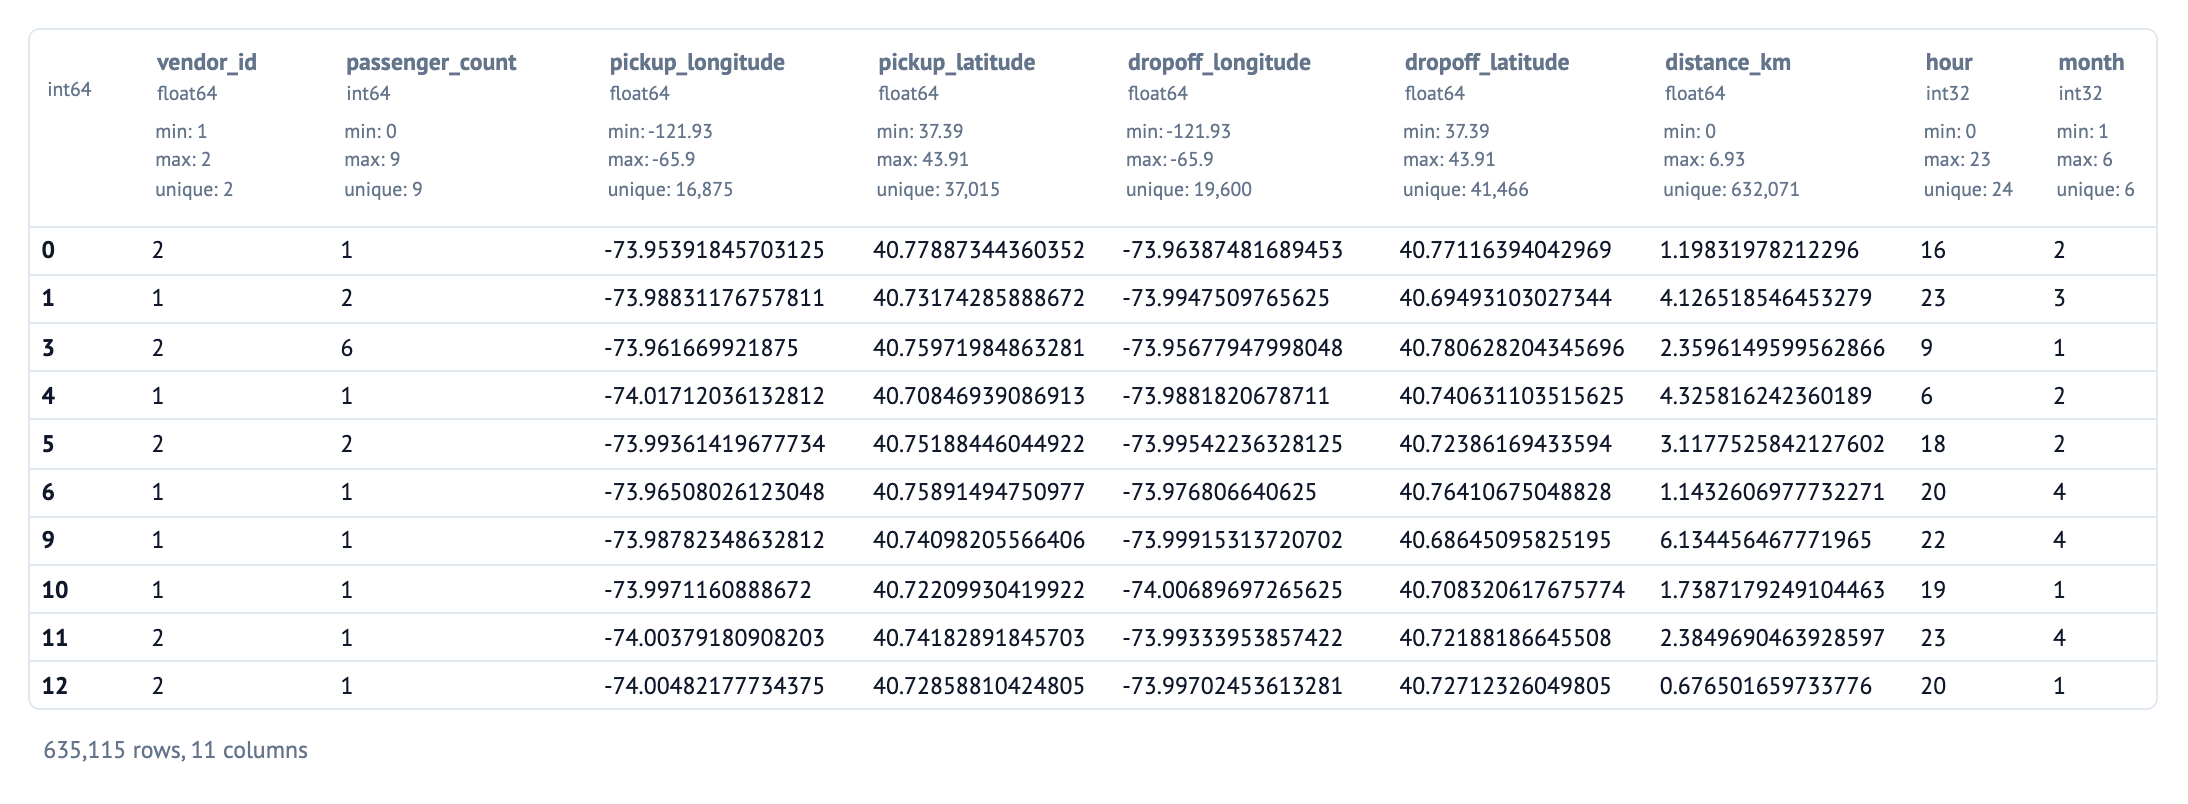

In [ ]:
def finilize_data(df):
    df = df.copy()

    df = df.drop(columns=["pickup_datetime", "time_of_day"])

    features = [c for c in df.columns if c != "trip_duration"]
    df = df[features + ["trip_duration"]]

    return df

df_final = finilize_data(df_filtered)
df_final

In [ ]:
save_path = "./data/processed/taxi.csv"
df_final.to_csv(save_path, index=False)